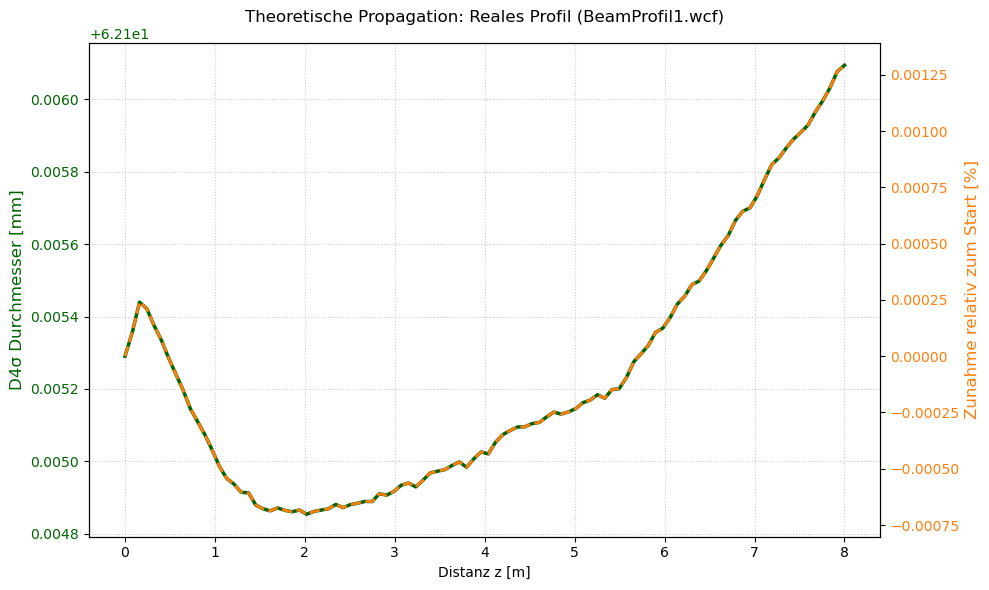

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os

# ==============================================================
# 1) PARAMETER & SETUP
# ==============================================================
lam            = 1064e-9      # Wellenlänge [m]
N              = 1024         # Auflösung (muss zur WCF passen)
L              = 60e-3        # Simulationsfenster [m]
dx             = L / N

# Propagations-Bereich
z_max          = 8.0          # Distanz [m]
z_steps        = 100
z_array        = np.linspace(0, z_max, z_steps)

# ==============================================================
# 2) FUNKTIONEN (WCF-Reader, Statistik, ASM)
# ==============================================================

def extract_2d_profile_from_wcf(filename):
    """Liest das 2D-Profil aus einer WCF-Datei."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")
    
    FILE_HEADER  = 5592
    FRAME_HEADER = 944

    with open(filename, "rb") as fobj:
        fobj.seek(FILE_HEADER)
        # Header lesen um Dimensionen zu prüfen (vereinfacht für N x N)
        header = fobj.read(FRAME_HEADER)
        # Datenblock lesen (16-bit uint)
        data = fobj.read(N * N * 2)
        frame = np.frombuffer(data, dtype=np.uint16).reshape((N, N)).astype(float)
    
    # Hintergrundabzug und Normierung
    frame -= np.min(frame)
    frame[frame < 0] = 0
    # Rückgabe der Amplitude (Wurzel der Intensität) für das Feld
    return np.sqrt(frame / np.max(frame)).astype(complex)

def get_d4sigma_mm(I, spatial_dx):
    """Berechnet D4sigma Durchmesser in mm."""
    h, w_px = I.shape
    x_c = (np.arange(w_px) - w_px/2) * spatial_dx
    y_c = (np.arange(h) - h/2) * spatial_dx
    X, Y = np.meshgrid(x_c, y_c)
    
    total = np.sum(I)
    if total <= 0: return 0.0
    P = I / total
    cx = np.sum(X * P)
    cy = np.sum(Y * P)
    
    sigma_sq = 0.5 * (np.sum(P * (X - cx)**2) + np.sum(P * (Y - cy)**2))
    return 4 * np.sqrt(max(sigma_sq, 0)) * 1000

def propagate_asm(U, dz):
    """Angular Spectrum Propagation."""
    k = 2 * np.pi / lam
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    kz = np.sqrt((k+0j)**2 - (2*np.pi*FX)**2 - (2*np.pi*FY)**2)
    return np.fft.ifft2(np.fft.fft2(U) * np.exp(1j * kz * dz))

# ==============================================================
# 3) SIMULATION (WCF-Profil)
# ==============================================================

# Startfeld aus WCF laden
try:
    U0 = extract_2d_profile_from_wcf("beamprofile1.wcf")
except Exception as e:
    print(f"Fehler: {e}")
    # Fallback: Dummy-Feld falls Datei fehlt
    X, Y = np.meshgrid((np.arange(N)-N/2)*dx, (np.arange(N)-N/2)*dx)
    U0 = np.exp(-(np.sqrt(X**2 + Y**2)/5e-3)**20).astype(complex)

d_vals = []
for zi in z_array:
    Uz = propagate_asm(U0, zi)
    d_vals.append(get_d4sigma_mm(np.abs(Uz)**2, dx))

d_vals = np.array(d_vals)
slope_pct = (d_vals - d_vals[0]) / d_vals[0] * 100

# ==============================================================
# 4) PLOTTING
# ==============================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Linke Achse: Absolutwerte
color_abs = 'darkgreen'
ax1.plot(z_array, d_vals, color=color_abs, lw=2.5, label='Absoluter Durchmesser (mm)')
ax1.set_xlabel("Distanz z [m]")
ax1.set_ylabel("D4σ Durchmesser [mm]", color=color_abs, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_abs)
ax1.grid(True, linestyle=':', alpha=0.6)

# Rechte Achse: Relative Steigung
ax2 = ax1.twinx()
color_slope = 'tab:orange'
ax2.plot(z_array, slope_pct, color=color_slope, ls='--', lw=2, label='Relative Steigung (%)')
ax2.set_ylabel("Zunahme relativ zum Start [%]", color=color_slope, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_slope)

plt.title("Theoretische Propagation: Reales Profil (BeamProfil1.wcf)", pad=15)
fig.tight_layout()
plt.show()